## Dataset Generation
### Importing Libraries

In [1]:
import numpy as np
import pandas as pd


### Setting Random Seed and Dataset Size

In [2]:
np.random.seed(42)
n = 2000

### Generating Customer Demographics and Account Information

In [3]:
customer_ids = [f"CUST-{i:04d}" for i in range(1, n+1)]

age = np.random.randint(18, 71, n)

gender = np.random.choice(['Male', 'Female'], n)

marital_status = np.random.choice(['Single', 'Married'], n)

dependents = np.random.choice(['Yes', 'No'], n)

location = np.random.choice(
    ['Karachi', 'Lahore', 'Islamabad', 'Peshawar', 'Quetta'], n)

contract_type = np.random.choice(
    ['Month-to-Month', 'One Year', 'Two Year'],
    n,
    p=[0.5, 0.3, 0.2]
)

payment_method = np.random.choice(
    ['Credit Card', 'Bank Transfer', 'Cash'], n)

monthly_charges = np.round(np.random.uniform(500, 8000, n), 2)

tenure_months = np.random.randint(1, 73, n)

phone_service = np.random.choice(['Yes', 'No'], n)

internet_service = np.random.choice(['Yes', 'No'], n)

streaming_service = np.random.choice(['Yes', 'No'], n)

customer_rating = np.random.randint(1, 6, n)

number_of_complaints = np.random.randint(0, 6, n)

late_payments = np.random.randint(0, 11, n)

last_interaction_days = np.random.randint(1, 366, n)

### Generating Churn Column Based on Business Logic

In [4]:
churn = []

for i in range(n):
    probability = 0.05
    
    # Risk factors - increase churn probability
    if contract_type[i] == 'Month-to-Month':
        probability += 0.15
    if monthly_charges[i] > 5000:
        probability += 0.20
    if tenure_months[i] < 12:
        probability += 0.10
    if customer_rating[i] < 3:
        probability += 0.15
    if number_of_complaints[i] > 3:
        probability += 0.10
    if late_payments[i] > 5:
        probability += 0.10
    
    # Protective factors - decrease churn probability
    if contract_type[i] == 'Two Year':
        probability -= 0.15
    if tenure_months[i] > 48:
        probability -= 0.10
    if dependents[i] == 'Yes':
        probability -= 0.05
    
    # Keep probability within realistic bounds
    probability = np.clip(probability, 0.05, 0.95)
    
    # Assign churn based on probability
    churn.append(np.random.binomial(1, probability))

### Assembling the Dataset

In [5]:
df = pd.DataFrame({
    'customer_id': customer_ids,
    'age': age,
    'gender': gender,
    'marital_status': marital_status,
    'dependents': dependents,
    'location': location,
    'contract_type': contract_type,
    'payment_method': payment_method,
    'monthly_charges': monthly_charges,
    'tenure_months': tenure_months,
    'phone_service': phone_service,
    'internet_service': internet_service,
    'streaming_service': streaming_service,
    'customer_rating': customer_rating,
    'number_of_complaints': number_of_complaints,
    'late_payments': late_payments,
    'last_interaction_days': last_interaction_days,
    'churn': churn
})

### Validating the Dataset

In [6]:
print("Dataset Shape:", df.shape)
print("\nChurn Distribution:")
print(df['churn'].value_counts())
print("\nChurn Rate:")
print(df['churn'].value_counts(normalize=True).round(3))
print("\nMissing Values:")
print(df.isnull().sum())
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (2000, 18)

Churn Distribution:
churn
0    1402
1     598
Name: count, dtype: int64

Churn Rate:
churn
0    0.701
1    0.299
Name: proportion, dtype: float64

Missing Values:
customer_id              0
age                      0
gender                   0
marital_status           0
dependents               0
location                 0
contract_type            0
payment_method           0
monthly_charges          0
tenure_months            0
phone_service            0
internet_service         0
streaming_service        0
customer_rating          0
number_of_complaints     0
late_payments            0
last_interaction_days    0
churn                    0
dtype: int64

First 5 Rows:


,customer_id,age,gender,marital_status,dependents,location,contract_type,payment_method,monthly_charges,tenure_months,phone_service,internet_service,streaming_service,customer_rating,number_of_complaints,late_payments,last_interaction_days,churn
0,CUST-0001,56,Male,Married,No,Karachi,Month-to-Month,Credit Card,1890.15,16,Yes,No,No,1,1,3,332,1
1,CUST-0002,69,Female,Single,No,Lahore,Month-to-Month,Cash,5257.47,20,No,No,No,5,4,4,37,0
2,CUST-0003,46,Female,Single,No,Peshawar,Two Year,Bank Transfer,6637.36,43,No,No,No,5,5,9,101,1
3,CUST-0004,32,Female,Married,No,Karachi,One Year,Bank Transfer,5306.41,44,No,Yes,Yes,4,3,3,31,0
4,CUST-0005,60,Female,Married,Yes,Islamabad,Month-to-Month,Cash,2827.99,47,No,No,No,1,4,7,190,0


In [7]:
df.describe()

,age,monthly_charges,tenure_months,customer_rating,number_of_complaints,late_payments,last_interaction_days,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,44.376500,4216.315640,36.168500,2.974000,2.513500,5.021000,183.911500,0.299000
std,15.226644,2158.500667,20.868346,1.391867,1.702724,3.136316,107.557836,0.457934
min,18.000000,501.390000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,31.000000,2408.760000,18.000000,2.000000,1.000000,2.000000,90.000000,0.000000
50%,45.000000,4190.600000,36.000000,3.000000,3.000000,5.000000,182.000000,0.000000
75%,57.000000,6040.542500,54.000000,4.000000,4.000000,8.000000,277.000000,1.000000
max,70.000000,7997.270000,72.000000,5.000000,5.000000,10.000000,365.000000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            2000 non-null   object 
 1   age                    2000 non-null   int32  
 2   gender                 2000 non-null   object 
 3   marital_status         2000 non-null   object 
 4   dependents             2000 non-null   object 
 5   location               2000 non-null   object 
 6   contract_type          2000 non-null   object 
 7   payment_method         2000 non-null   object 
 8   monthly_charges        2000 non-null   float64
 9   tenure_months          2000 non-null   int32  
 10  phone_service          2000 non-null   object 
 11  internet_service       2000 non-null   object 
 12  streaming_service      2000 non-null   object 
 13  customer_rating        2000 non-null   int32  
 14  number_of_complaints   2000 non-null   int32  
 15  late

## Phase 1 Summary: Dataset Creation

### What We Did:
- Designed an 18-column synthetic telecom dataset representing Pakistani customers
- Generated 2000 records using NumPy with realistic value ranges
- Implemented probability-based churn logic using 6 risk factors and 3 protective factors
- Validated dataset shape, missing values, and churn rate

### Key Decisions:
- Used PKR for monetary values to reflect Pakistani telecom context
- Chose 30% churn rate to reflect real-world class imbalance
- Used weighted probabilities for contract_type distribution (50% Month-to-Month)
- Set random seed 42 for reproducibility

### Dataset Statistics:
- Total Records: 2000
- Total Features: 18
- Churn Rate: ~30%
- Missing Values: 0

## Exploratory Data Analysis
### 2.1 Churn Distribution

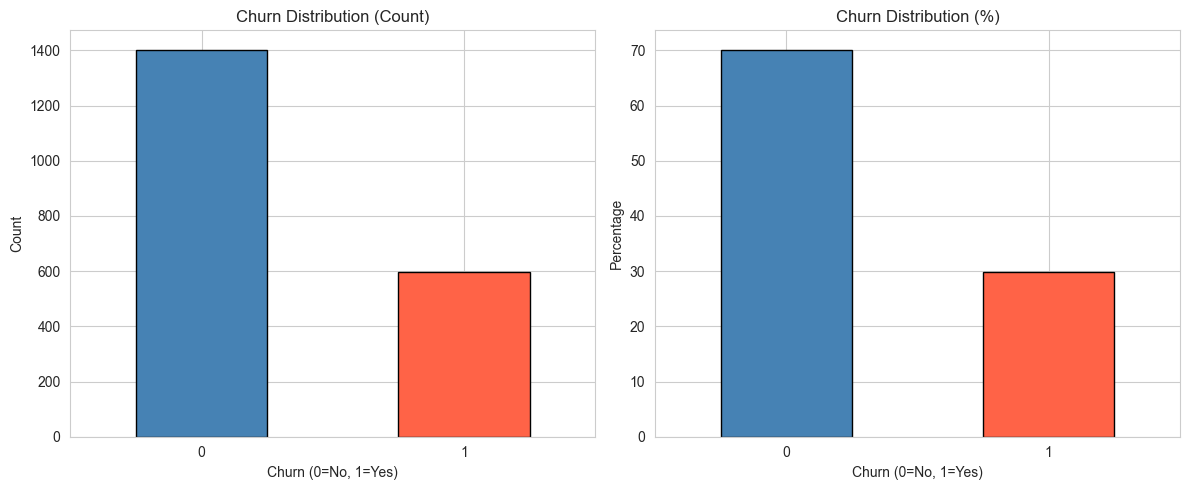

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Churn Count
df['churn'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_xlabel('Churn (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Chart 2: Churn Percentage
df['churn'].value_counts(normalize=True).mul(100).plot(
    kind='bar',
    ax=axes[1],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[1].set_title('Churn Distribution (%)')
axes[1].set_xlabel('Churn (0=No, 1=Yes)')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Numerical Feature Distributions

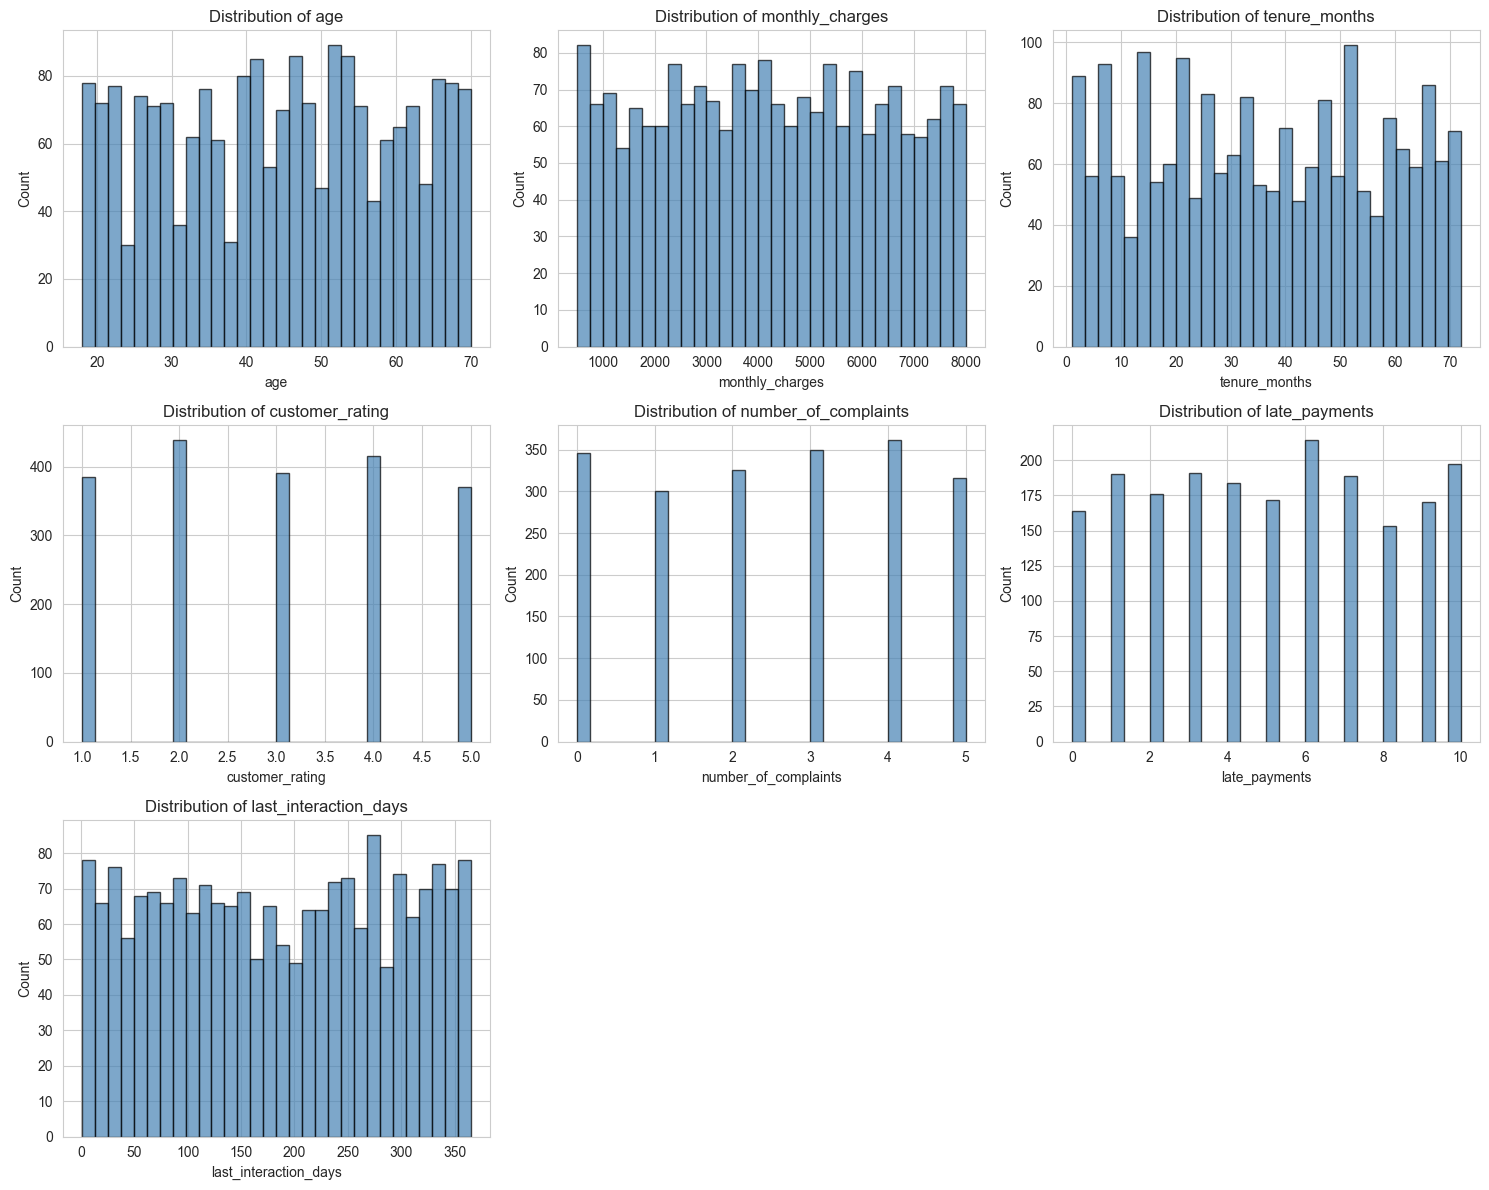

In [10]:
numerical_cols = ['age', 'monthly_charges', 'tenure_months', 
                  'customer_rating', 'number_of_complaints', 
                  'late_payments', 'last_interaction_days']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', 
                 edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide empty subplot
axes[7].set_visible(False)
axes[8].set_visible(False)

plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Churn vs Categorical Features

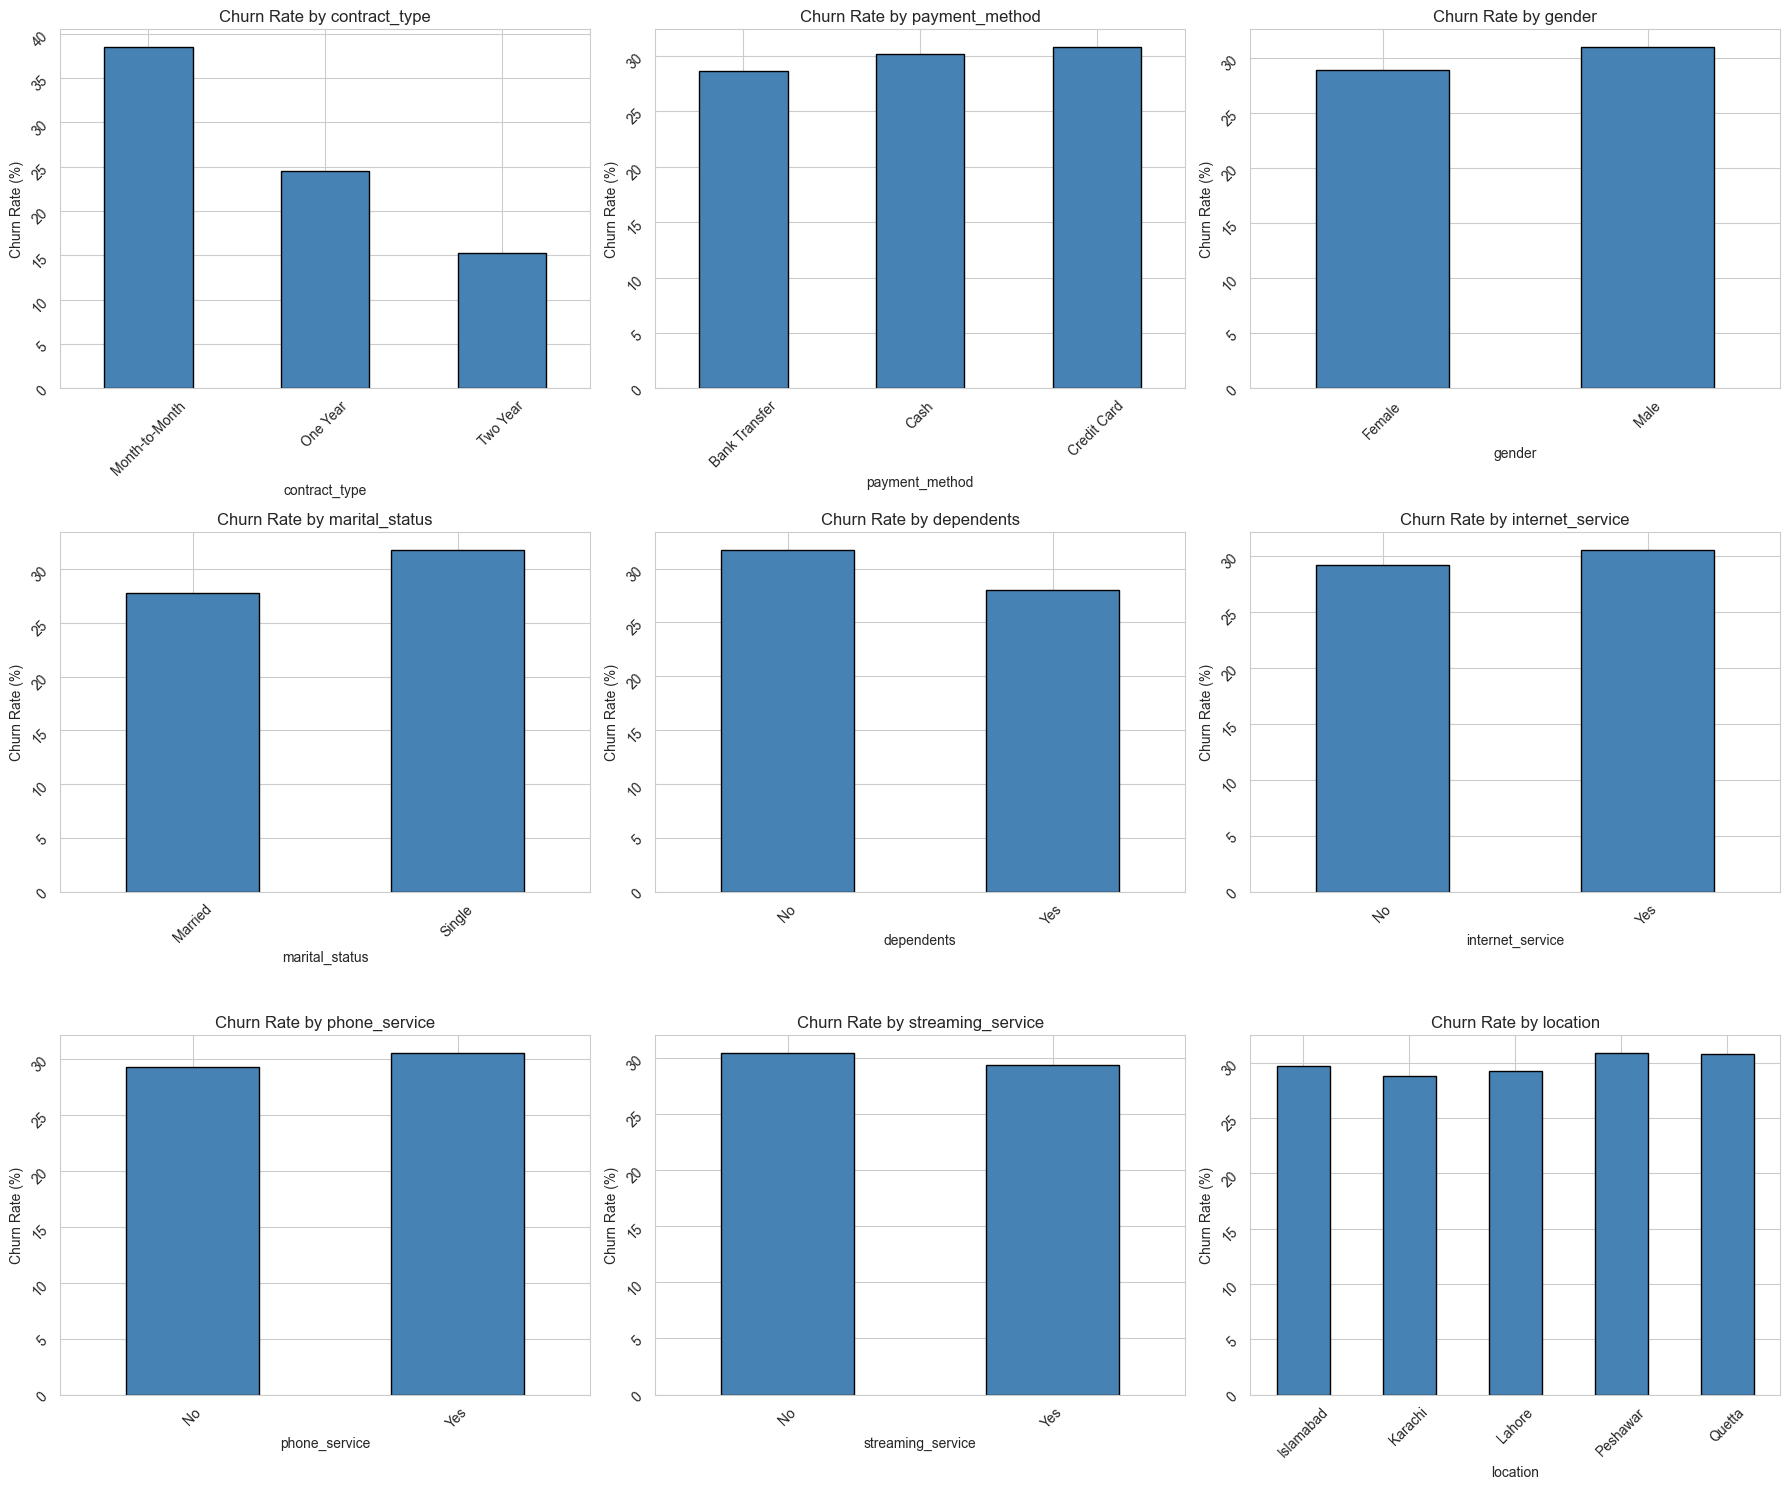

In [11]:
categorical_cols = ['contract_type', 'payment_method', 'gender',
                   'marital_status', 'dependents', 'internet_service',
                   'phone_service', 'streaming_service', 'location']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['churn'].mean() * 100
    churn_rate.plot(
        kind='bar',
        ax=axes[i],
        color='steelblue',
        edgecolor='black'
    )
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(rotation=45)

plt.tight_layout()
plt.savefig('categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Churn vs Numerical Features

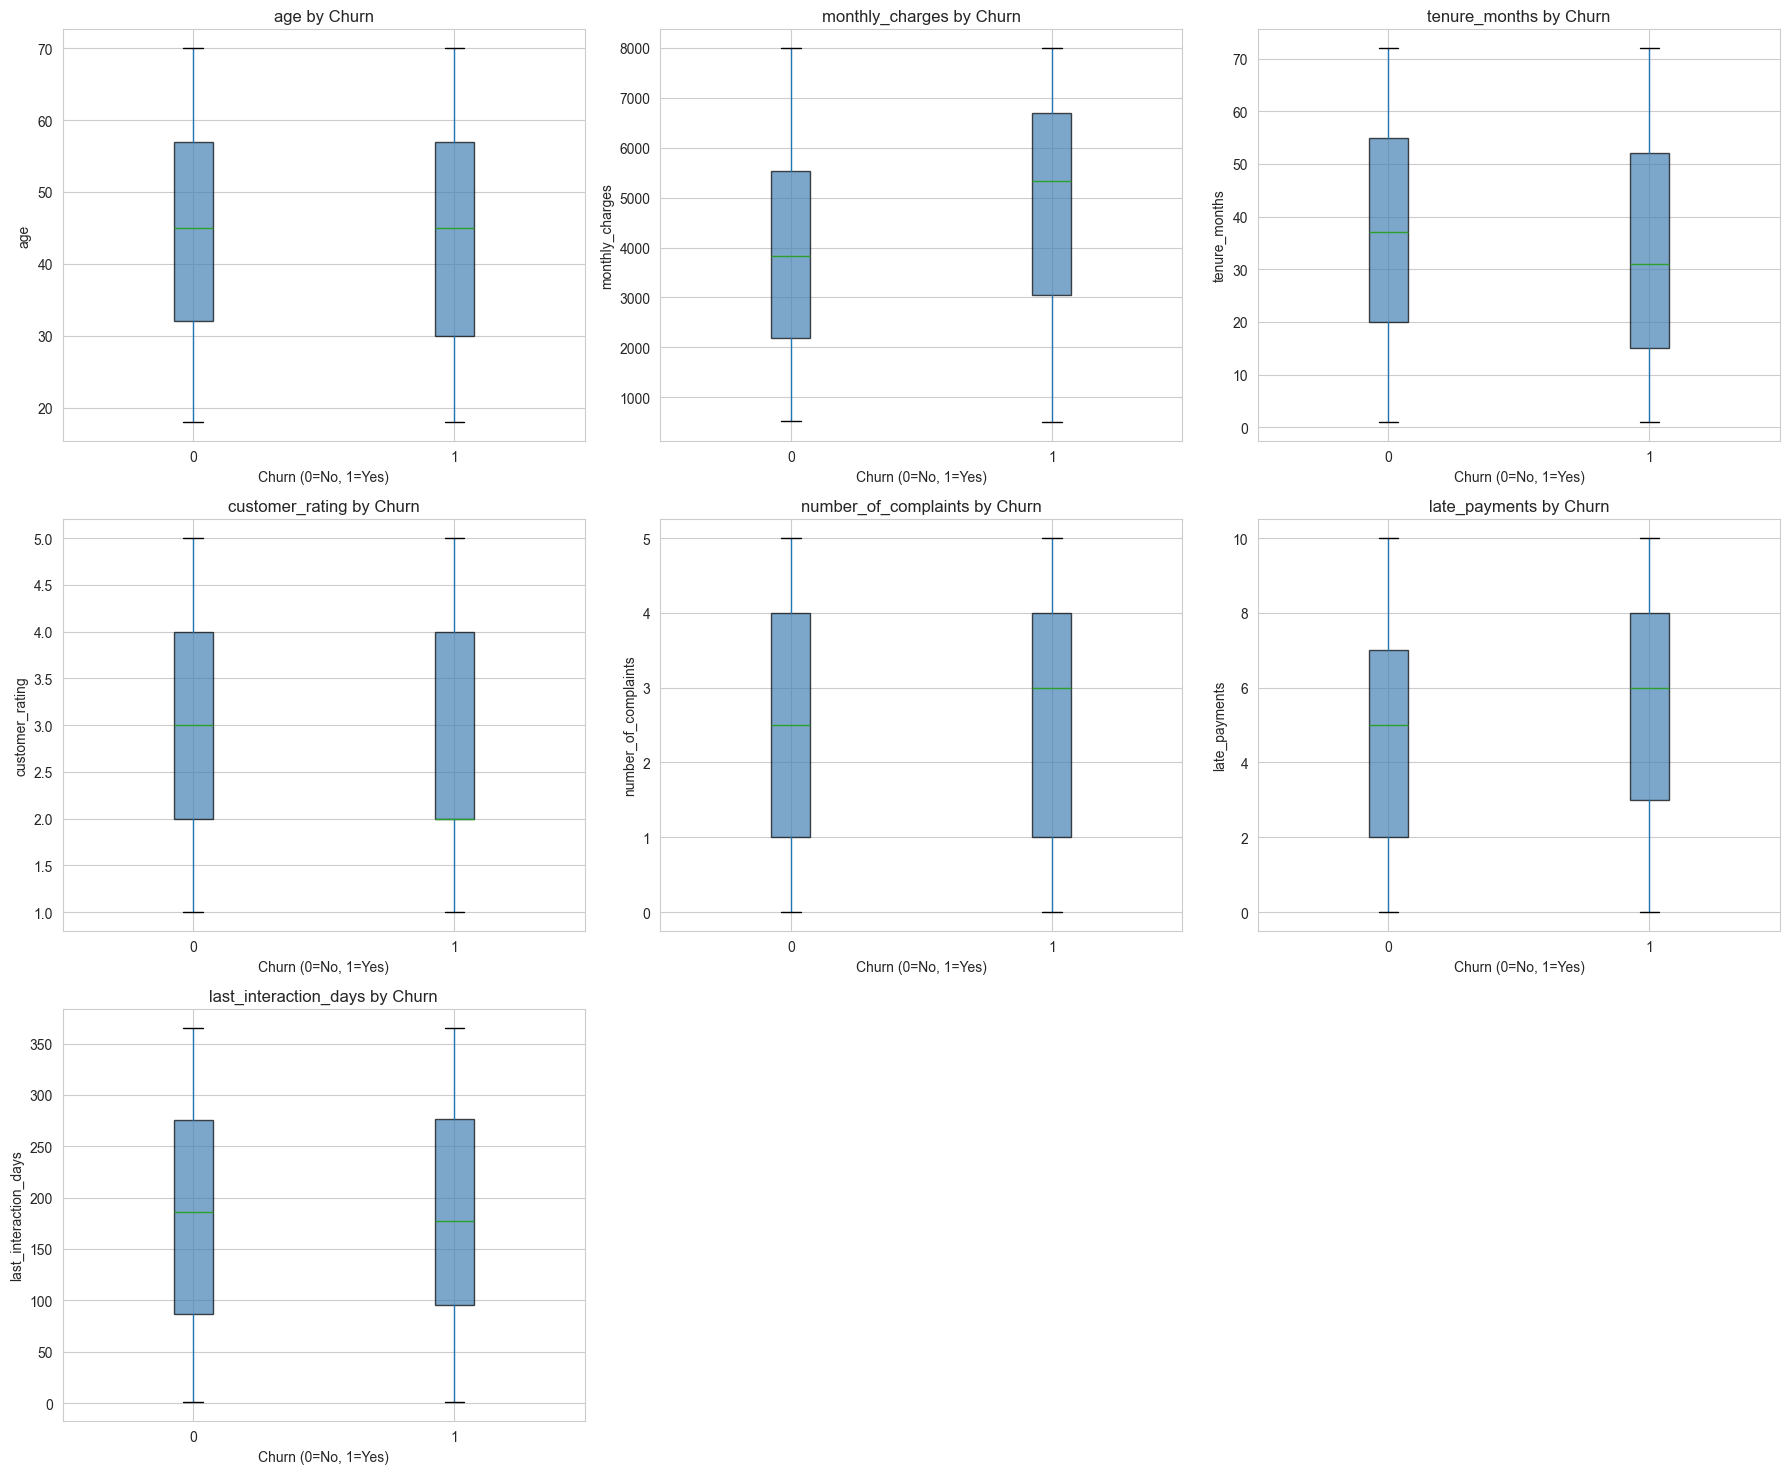

In [12]:
numerical_cols = ['age', 'monthly_charges', 'tenure_months',
                  'customer_rating', 'number_of_complaints',
                  'late_payments', 'last_interaction_days']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df.boxplot(
        column=col,
        by='churn',
        ax=axes[i],
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7)
    )
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn (0=No, 1=Yes)')
    axes[i].set_ylabel(col)

# Hide empty subplots
axes[7].set_visible(False)
axes[8].set_visible(False)

plt.suptitle('')
plt.tight_layout()
plt.savefig('numerical_churn_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Correlation Heatmap

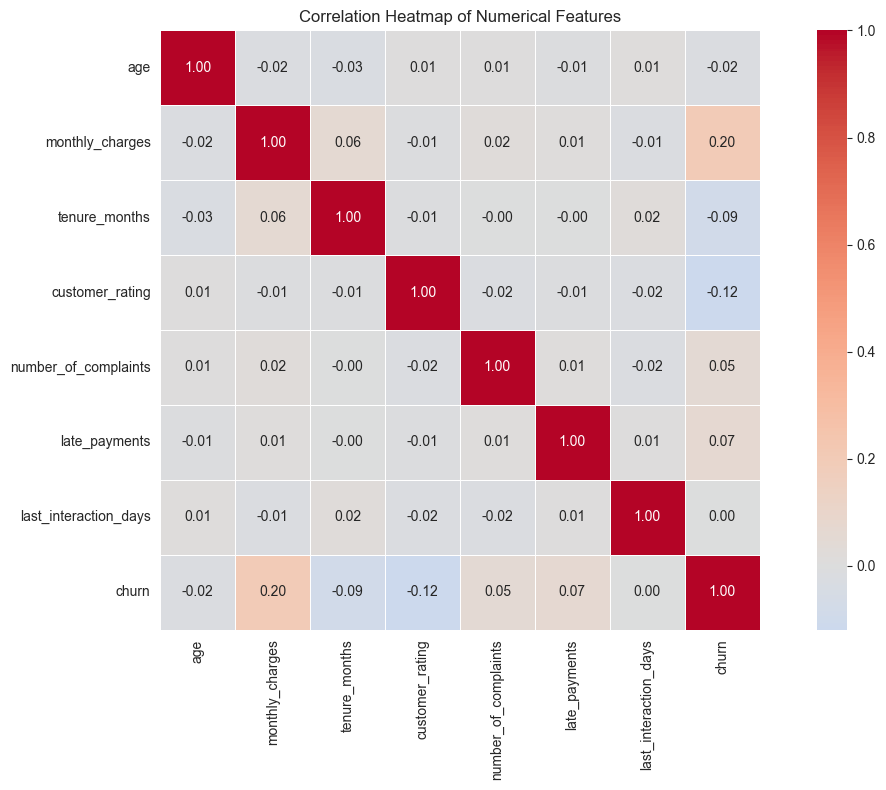

In [13]:
plt.figure(figsize=(12, 8))

numerical_df = df[['age', 'monthly_charges', 'tenure_months',
                    'customer_rating', 'number_of_complaints',
                    'late_payments', 'last_interaction_days', 'churn']]

correlation_matrix = numerical_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 2 Summary: Exploratory Data Analysis

### What We Did:
- Analyzed churn distribution and confirmed class imbalance (70/30)
- Visualized numerical feature distributions
- Compared churn rates across categorical features
- Used boxplots to compare numerical features between churned and non-churned customers
- Generated correlation heatmap for numerical features

### Key Findings:
- contract_type is the strongest categorical predictor — Month-to-Month customers churn at 40%+
- monthly_charges shows highest numerical correlation with churn (0.20)
- tenure_months confirms design logic — shorter tenure leads to higher churn
- gender, location, payment_method, phone_service, streaming_service show minimal churn variation
- last_interaction_days shows no meaningful difference between churned and non-churned customers

### Limitations:
- Numerical features follow uniform distributions due to synthetic generation
- Real telecom data would show skewed distributions in tenure and monthly charges
- Weak numerical correlations with churn are characteristic of synthetic noise

### Features Flagged for Review in Feature Engineering:
- Low predictive power: age, gender, location, last_interaction_days, payment_method
- Strong predictors to retain: contract_type, monthly_charges, tenure_months, customer_rating

## Phase 3: Data Preparation

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Step 1: Drop customer_id
df_prepared = df.drop(columns=['customer_id'])

# Step 2: Encode binary categorical columns
binary_cols = ['gender', 'marital_status', 'dependents',
               'phone_service', 'internet_service', 'streaming_service']

le = LabelEncoder()
for col in binary_cols:
    df_prepared[col] = le.fit_transform(df_prepared[col])

# Step 3: One-hot encode multi-category columns
df_prepared = pd.get_dummies(
    df_prepared,
    columns=['contract_type', 'payment_method', 'location'],
    drop_first=True
)

# Step 4: Separate features and target
X = df_prepared.drop(columns=['churn'])
y = df_prepared['churn']

# Step 5: Scale numerical columns
scaler = StandardScaler()
numerical_cols = ['age', 'monthly_charges', 'tenure_months',
                  'customer_rating', 'number_of_complaints',
                  'late_payments', 'last_interaction_days']

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Step 6: Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nFeature columns:", list(X.columns))
print("\nTraining churn rate:", y_train.mean().round(3))
print("Testing churn rate:", y_test.mean().round(3))

Training set size: (1600, 21)
Testing set size: (400, 21)

Feature columns: ['age', 'gender', 'marital_status', 'dependents', 'monthly_charges', 'tenure_months', 'phone_service', 'internet_service', 'streaming_service', 'customer_rating', 'number_of_complaints', 'late_payments', 'last_interaction_days', 'contract_type_One Year', 'contract_type_Two Year', 'payment_method_Cash', 'payment_method_Credit Card', 'location_Karachi', 'location_Lahore', 'location_Peshawar', 'location_Quetta']

Training churn rate: 0.299
Testing churn rate: 0.3


## Phase 3 Summary: Data Preparation

In this phase, the raw dataset was cleaned and transformed into a 
format that machine learning models can understand and learn from 
effectively.

The first step was dropping the customer_id column since it is just 
an identifier and carries no predictive value for churn.

Next, all categorical columns were encoded into numerical values. 
Machine learning models cannot understand text like "Male", "Female", 
"Yes", "No", or "Month-to-Month". Binary columns like gender and 
dependents were encoded using Label Encoding (0 and 1), while 
multi-category columns like contract_type, payment_method, and 
location were encoded using One-Hot Encoding to avoid creating any 
false numerical order between categories.

After encoding, numerical columns were scaled using StandardScaler. 
Features like monthly_charges (500-8000) and age (18-70) operate on 
very different scales. Without scaling, the model assumes larger 
numbers are more important, which creates bias. Scaling brings all 
features to the same range so the model judges them fairly.

Finally, the data was split into 80% training and 20% testing sets. 
The stratify parameter was used to ensure both sets maintain the same 
churn rate as the original dataset (approximately 30%). This guarantees 
a fair and reliable model evaluation.

After preparation:
- Training set: 1600 rows
- Testing set: 400 rows
- Total features: 21
- Churn rate preserved in both sets

## Phase 4: Feature Engineering

In [15]:
# Step 1: Create new features
X_train['number_of_services'] = (X_train['phone_service'] + 
                                  X_train['internet_service'] + 
                                  X_train['streaming_service'])

X_test['number_of_services'] = (X_test['phone_service'] + 
                                 X_test['internet_service'] + 
                                 X_test['streaming_service'])

X_train['total_charges'] = (X_train['monthly_charges'] * 
                             X_train['tenure_months'])

X_test['total_charges'] = (X_test['monthly_charges'] * 
                            X_test['tenure_months'])

# Step 2: Drop weak features
weak_features = ['gender', 'last_interaction_days',
                 'location_Karachi', 'location_Lahore',
                 'location_Peshawar', 'location_Quetta',
                 'payment_method_Cash', 'payment_method_Credit Card']

X_train = X_train.drop(columns=weak_features)
X_test = X_test.drop(columns=weak_features)

print("Features after engineering:", list(X_train.columns))
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Features after engineering: ['age', 'marital_status', 'dependents', 'monthly_charges', 'tenure_months', 'phone_service', 'internet_service', 'streaming_service', 'customer_rating', 'number_of_complaints', 'late_payments', 'contract_type_One Year', 'contract_type_Two Year', 'number_of_services', 'total_charges']
Training set shape: (1600, 15)
Testing set shape: (400, 15)


## Phase 4 Summary: Feature Engineering

In this phase, I improved the dataset by creating meaningful new 
features and removing columns that were not contributing to churn 
prediction.

Two new features were created:

1. number_of_services: Created by adding phone_service, 
internet_service, and streaming_service together. This gives a 
single score (0 to 3) representing how many services a customer 
uses. Customers using more services have higher switching costs 
and are less likely to churn.

2. total_charges: Created by multiplying monthly_charges by 
tenure_months. This represents the total amount a customer has 
paid to

## Phase 5: Model Building

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

# Model 1: Logistic Regression
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_probability = lr_model.predict_proba(X_test)[:, 1]

# Model 2: Random Forest
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_probability = rf_model.predict_proba(X_test)[:, 1]

print("Both models trained successfully.")
print("Logistic Regression - Training Score:", 
      round(lr_model.score(X_train, y_train), 3))
print("Random Forest - Training Score:", 
      round(rf_model.score(X_train, y_train), 3))

Both models trained successfully.
Logistic Regression - Training Score: 0.642
Random Forest - Training Score: 1.0


## Phase 6: Model Evaluation

In [17]:
# Logistic Regression Evaluation
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(classification_report(y_test, lr_predictions))
print("ROC-AUC Score:", round(roc_auc_score(y_test, lr_probability), 3))

print("\n" + "=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, rf_predictions))
print("ROC-AUC Score:", round(roc_auc_score(y_test, rf_probability), 3))

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.81      0.62      0.70       280
           1       0.43      0.65      0.51       120

    accuracy                           0.63       400
   macro avg       0.62      0.64      0.61       400
weighted avg       0.69      0.63      0.65       400

ROC-AUC Score: 0.715

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.72      0.93      0.81       280
           1       0.50      0.17      0.26       120

    accuracy                           0.70       400
   macro avg       0.61      0.55      0.54       400
weighted avg       0.66      0.70      0.65       400

ROC-AUC Score: 0.695


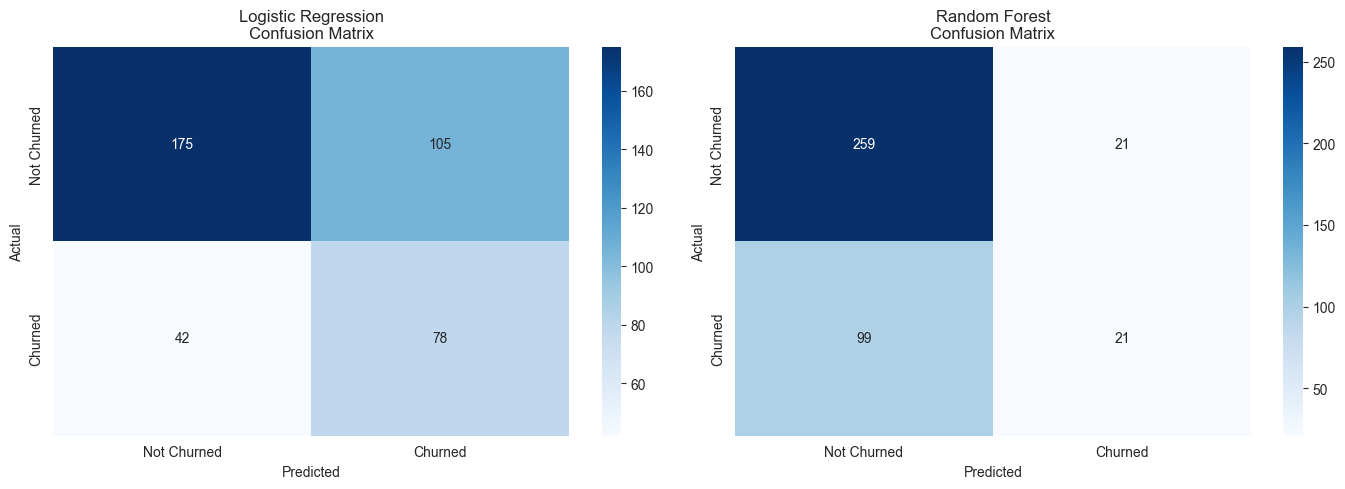

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            ax=axes[0],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            ax=axes[1],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

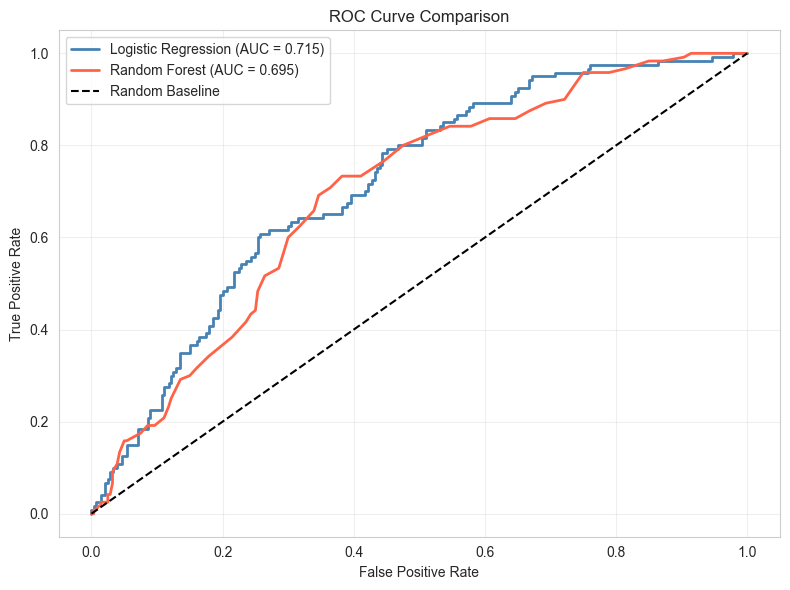

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probability)
ax.plot(fpr_lr, tpr_lr, 
        label=f'Logistic Regression (AUC = 0.715)',
        color='steelblue', linewidth=2)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probability)
ax.plot(fpr_rf, tpr_rf,
        label=f'Random Forest (AUC = 0.695)',
        color='tomato', linewidth=2)

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', label='Random Baseline')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 5 & 6 Summary: Model Building and Evaluation

In this phase, two models were built and compared to find the best 
churn predictor.

Both models used class_weight='balanced' to handle class imbalance. 
This tells the model to pay extra attention to churners even though 
they are the minority class.

Logistic Regression works by calculating the probability of churn 
for each customer and drawing the best possible boundary between 
churners and non-churners.

Random Forest works by building 100 decision trees, each asking a 
series of yes/no questions about the customer. The final prediction 
is based on majority voting across all trees.

During evaluation, Random Forest showed a training score of 100% 
which is a clear sign of overfitting. This means the model memorized 
the training data instead of learning real patterns. As a result it 
failed badly on test data, catching only 21 out of 120 actual churners.

For a churn prediction system, recall is the most important metric 
because missing a churner means losing a customer forever. Accuracy 
alone is misleading in imbalanced problems.

Logistic Regression was selected as the final model because:
- Recall for churners: 0.65 vs Random Forest 0.17
- ROC-AUC: 0.715 vs Random Forest 0.695
- Caught 78 out of 120 actual churners vs only 21 for Random Forest

The logistic regression model is not perfect but it is significantly 
better at identifying customers who are about to leave, which is the 
core business objective.

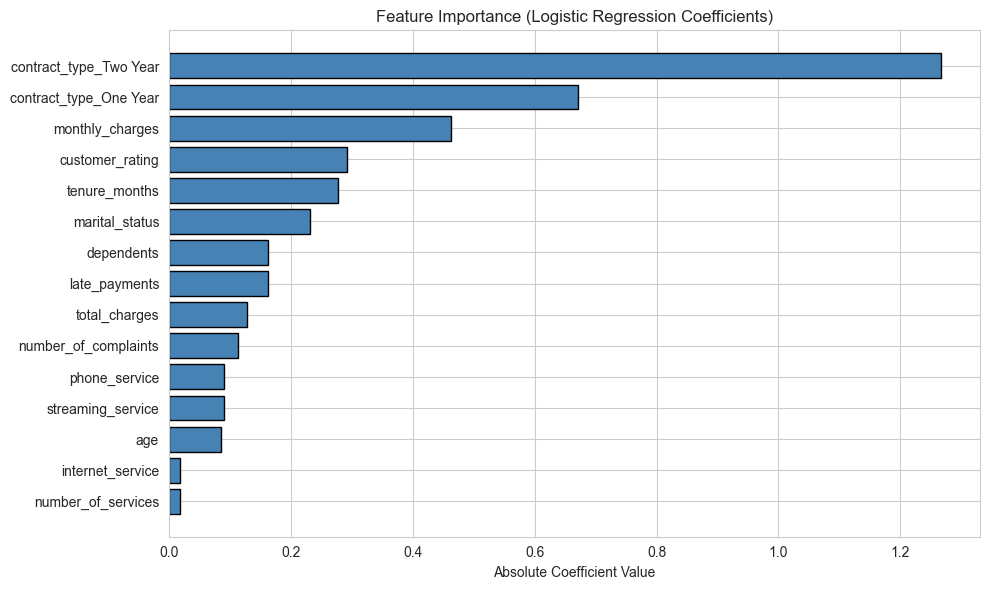

In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

# Feature importance from Logistic Regression
feature_names = X_train.columns.tolist()
coefficients = lr_model.coef_[0]
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': np.abs(coefficients)
}).sort_values('importance', ascending=True)

def show_feature_importance():
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'], 
             feature_importance['importance'],
             color='steelblue', edgecolor='black')
    plt.title('Feature Importance (Logistic Regression Coefficients)')
    plt.xlabel('Absolute Coefficient Value')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

show_feature_importance()

In [23]:
# Step 1: Reload original dataframe
import joblib
df_clean = pd.read_csv('telecom_churn_dataset.csv')

# Step 2: Drop customer_id
df_clean = df_clean.drop(columns=['customer_id'])

# Step 3: Encode binary columns
binary_cols = ['gender', 'marital_status', 'dependents',
               'phone_service', 'internet_service', 
               'streaming_service']
le2 = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le2.fit_transform(df_clean[col])

# Step 4: One-hot encode
df_clean = pd.get_dummies(
    df_clean,
    columns=['contract_type', 'payment_method', 'location'],
    drop_first=True
)

# Step 5: Feature engineering
df_clean['number_of_services'] = (
    df_clean['phone_service'] + 
    df_clean['internet_service'] + 
    df_clean['streaming_service']
)
df_clean['total_charges'] = (
    df_clean['monthly_charges'] * 
    df_clean['tenure_months']
)

# Step 6: Drop weak features
weak_features = ['gender', 'last_interaction_days',
                 'location_Karachi', 'location_Lahore',
                 'location_Peshawar', 'location_Quetta',
                 'payment_method_Cash', 
                 'payment_method_Credit Card']
df_clean = df_clean.drop(columns=weak_features)

# Step 7: Separate features and target
X_final = df_clean.drop(columns=['churn'])
y_final = df_clean['churn']

# Step 8: Train test split
X_train_final, X_test_final, y_train_final, y_test_final = \
    train_test_split(
        X_final, y_final,
        test_size=0.2,
        random_state=42,
        stratify=y_final
    )

# Step 9: Scale ONLY numerical columns
numerical_cols_final = ['age', 'monthly_charges', 
                        'tenure_months', 'customer_rating',
                        'number_of_complaints', 'late_payments']

scaler_final = StandardScaler()
X_train_final[numerical_cols_final] = \
    scaler_final.fit_transform(
        X_train_final[numerical_cols_final])
X_test_final[numerical_cols_final] = \
    scaler_final.transform(
        X_test_final[numerical_cols_final])

# Step 10: Train model
lr_final = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_final.fit(X_train_final, y_train_final)

# Step 11: Evaluate
from sklearn.metrics import classification_report
lr_preds_final = lr_final.predict(X_test_final)
print(classification_report(y_test_final, lr_preds_final))

# Step 12: Save everything
joblib.dump(lr_final, 'churn_model.pkl')
joblib.dump(scaler_final, 'scaler.pkl')
joblib.dump(X_train_final.columns.tolist(), 'feature_names.pkl')

print("\nAll files saved successfully.")
print("Features:", X_train_final.columns.tolist())

              precision    recall  f1-score   support

           0       0.81      0.63      0.71       280
           1       0.43      0.66      0.52       120

    accuracy                           0.64       400
   macro avg       0.62      0.65      0.62       400
weighted avg       0.70      0.64      0.65       400


All files saved successfully.
Features: ['age', 'marital_status', 'dependents', 'monthly_charges', 'tenure_months', 'phone_service', 'internet_service', 'streaming_service', 'customer_rating', 'number_of_complaints', 'late_payments', 'contract_type_One Year', 'contract_type_Two Year', 'number_of_services', 'total_charges']


## Final Report

### Project Summary
This project built a complete customer churn prediction system 
for a Pakistani telecom company from scratch. A synthetic dataset 
of 2000 customers was designed and generated with realistic churn 
logic, explored through EDA, prepared for modeling, and used to 
train a Logistic Regression model deployed in an interactive 
Streamlit dashboard.

### Dataset Description
- 2000 records, 18 features
- Pakistani telecom context with PKR currency and Pakistani cities
- Churn rate: 30% (realistic class imbalance)
- Churn logic based on contract type, monthly charges, tenure, 
  complaints, late payments, and customer rating

### Data Preparation Process
- Dropped customer_id (identifier, no predictive value)
- Label encoded binary categorical columns
- One-hot encoded multi-category columns
- Scaled numerical features using StandardScaler
- Train-test split: 80/20 with stratification

### Feature Engineering
- Created number_of_services from phone, internet, 
  and streaming service columns
- Created total_charges by multiplying monthly charges 
  and tenure months
- Dropped 7 weak features identified during EDA

### Model Selection
Two models were trained and compared:
- Logistic Regression with class_weight=balanced
- Random Forest with class_weight=balanced

Logistic Regression was selected as the final model because 
it achieved 66% recall for churners versus only 17% for 
Random Forest. In churn prediction, recall is the most 
important metric because missing a churner means losing a 
customer forever.

### Evaluation Results
Logistic Regression:
- Accuracy: 64%
- Precision (Churn): 43%
- Recall (Churn): 66%
- F1 Score (Churn): 52%
- ROC-AUC: 0.715

Random Forest:
- Accuracy: 70%
- Precision (Churn): 50%
- Recall (Churn): 17%
- F1 Score (Churn): 26%
- ROC-AUC: 0.695

### Key Findings
1. Contract type is the strongest churn predictor. 
   Month-to-Month customers churn at 40%+ while Two Year 
   customers churn at only 16%.
2. High monthly charges significantly increase churn risk. 
   Customers paying above PKR 5000 monthly are at higher risk.
3. New customers churn more. Customers with less than 12 months 
   tenure have significantly higher churn probability.
4. High complaints and late payments are strong warning signals.
5. Customers with dependents churn less due to higher 
   switching costs.
6. Features like gender, location, and payment method showed 
   almost no influence on churn.

### Business Recommendations
1. IMMEDIATE ACTION — Contact all Month-to-Month customers 
   with contract upgrade offers. A 20% discount on One Year 
   contracts could significantly reduce churn.
2. NEW CUSTOMER PROGRAM — Customers in their first 12 months 
   need special attention. Assign welcome programs and 
   dedicated support.
3. COMPLAINT RESOLUTION — Any customer with more than 3 
   complaints should receive a personal call within 24 hours.
4. MONTHLY RISK SCREENING — Use the batch prediction feature 
   to screen all customers monthly and proactively reach out 
   to high risk segments.
5. PRICING REVIEW — High monthly charges are a major churn 
   driver. Consider loyalty discounts for long-term customers 
   paying above PKR 5000.

### Limitations
1. Dataset is synthetic — real telecom data would produce 
   stronger model performance.
2. Logistic Regression accuracy of 64% leaves room for 
   improvement with more advanced models like XGBoost.
3. Uniform distributions in numerical features are a 
   characteristic of synthetic data generation.
4. Model was not tested on real customer data.

### Future Improvements
1. Collect real telecom customer data for retraining
2. Try XGBoost and Neural Networks for better performance
3. Add SHAP explainability for individual predictions
4. Implement hyperparameter tuning
5. Deploy dashboard on Streamlit Cloud for public access